### Ornstein-Uhlenbeck Process (OU Process)
The OU Process is a stochastic model for mean-reversion. He describe a variable who tend to return to a long-term mean, while being pertubated by a gaussian noise.

The defining SDE is the following :

$$ dX_t = θ(μ-X_t)dt + σdW_t $$

with :

- $ θ > 0 $ the speed of mean reversion

- μ the long-term mean (equilibrium level)

- σ the volatility (intensity of the noise)

- $ W_t $ Standard Brownian motion


The SDE is linear, so it admits an explicit solution via the integrating factor
$ e^{θt} $ :

$$ X_t ​= μ+(X_0​−μ)e−θ_t+σ∫_0^t e^{−θ(t-s)} dW_s​ $$

There is two key properties :  

- Conditional Distribution - Which means that $X_t ​∣ X_0​ $ is Gaussian

<br>

$$ 𝔼[X_t ​∣ X_0 ] = μ + (X_0 - μ) e^{-θt}$$

$$ Var(X_t ​∣ X_0) = \frac{σ^2}{2θ}(1-e^{-2θt}) $$

<br>

- Stationnary Distribution - as $ t → ∞ $

$$ X_{∞} ∼ \mathcal{N}(μ,\frac{σ2}{2θ}​) $$

<br>

The process is ergodic and stationary: it does not diverge, unlike GBM. Half-life is the time required to absorb half of a deviation from the mean:  $$ t_{1/2} = \frac{\ln \space 2} {θ} $$



#### Geometric Intuition

- If $ X_t > μ $, the drift $ θ(μ - X_t) < 0$ pushes downward

- If $ X_t < 0 $, the drift pushes upward

- σ control the agitation around the mean

- The larger is θ, the faster is the reversion, because the shorter is the half-life

#### Parameters Estimation

On discrete data, with a time step $ Δt $, we have to regress :

$$ X_{t+Δt}​−X_t​=α+βX_t​+ε_t​ $$

Then we can recover :

&emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; &emsp; $ \theta = -\frac{\ln(1+β)}{Δt}$ &emsp; &emsp; &emsp; &emsp; $ \mu = -\frac{α}{β}$ &emsp; &emsp; &emsp; &emsp; $ σ = σ_ɛ\sqrt{\frac{2θ}{1-e^{-2θΔt}}} $

<br>

Few exemple of diverse application of OU Process in quant finance :

<br>

- Pairs Trading / Stat-arb : The cointegrated spread follows an OU → entry/exit signal

- Interest rates : Vasicek model

- Stochastic volatility : Log-vol in certain models (e.g. rough SABR)

- Optimal execution : Avellaneda-Stoikov: market maker inventory follows an OU

### Limits (some of them)

#### 1°/ Constant parameters :

The model assume that $ (θ, μ, σ) $ are constant, which is obviously wrong.
<br>

- Mean reversion regime change. The spread can drift (M&A cases for exemple)
- μ drifts : The cointegration is never perfectly stable
- σ is not constants, σ is stochastic

Then, a θ calibrated on a passed window is often unstable out-of-sample. Half life can double, depending on the chosen window.

<br>

#### 2°/ Thin tails :

With OU, increments are exactly Gaussian. In the reality, there is :
- Kurtosis (fat tails) : Extreme events are underestimated
- Skewness ≠ 0 : Asyymetric tails
- Jumps : (Earnings, unexpected macro-events, ...)

Then, the model underestimate the probability that the spread get brutally out of his range, which get wrong the sizing and the risk management

<br>

#### 3°/ Cointegration Instability :

It's the most critical limit when it comes to trading
- The relation of the cointegration $ ɛ_t = P^A - βP^B $ assume that β is constant. But, β drifts.
- The pairs who was cointegrated during 2 years or more can not be anymore. The spread become a random walk and the signal from OU become horrible.
- Tests like ADF isn't very powerful when it comes to short windows and reject cointegration

Then, the real risk is to calibrate an OU on a non stationary spread. The model gonna detect a non-existing mean reversion, enter in position, and the spread will continue to drift

### What can we do to compensate those limits ?

In order to have something stronger, we have to combine :

- Kalman filters : We can estimate $ (β_t, μ_t) $ dynamicaly
- Monitorate the stationnarity in live : ADF Rolling, or a test like CUSUM which can detect breakpoints
- Volatility scaling of the signal : Divide the z-score by the most recent volatility of the spread
- Have a fixed stop loss on the z-score, even if its tight : For exemple, cut if $ ∣z∣>4 $ to protect against permanent divergences

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2a2d45',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#475569',
    'ytick.color':      '#475569',
    'text.color':       '#e2e8f0',
    'grid.color':       '#2a2d45',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'axes.grid':        True,
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#2a2d45',
    'figure.figsize':   (14, 5),
})

PURPLE = '#818cf8'
GREEN  = '#34d399'
ORANGE = '#fb923c'
RED    = '#f87171'
YELLOW = '#fbbf24'

Train: 2015-01-02 → 2022-12-28  (2012 days)
Test : 2022-12-29  → 2023-12-29  (252 days)


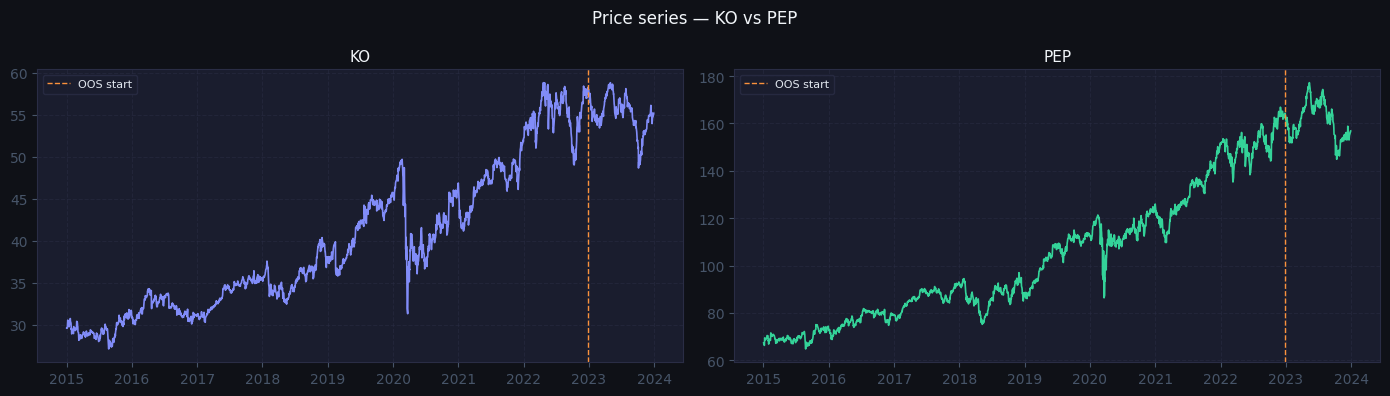

In [2]:
TICKER_A = 'KO'
TICKER_B = 'PEP'
START    = '2015-01-01'
END      = '2024-01-01'

raw = yf.download([TICKER_A, TICKER_B], start=START, end=END, progress=False)['Close']
prices = raw.dropna()
prices.columns = [TICKER_A, TICKER_B]

# Train / test split — last 252 days = out-of-sample
SPLIT    = -252
train    = prices.iloc[:SPLIT]
test     = prices.iloc[SPLIT:]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} days)")
print(f"Test : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} days)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color in zip(axes, [TICKER_A, TICKER_B], [PURPLE, GREEN]):
    ax.plot(prices.index, prices[col], color=color, lw=1.2)
    ax.axvline(test.index[0], color=ORANGE, lw=1, linestyle='--', label='OOS start')
    ax.set_title(col, fontsize=11, color='#f1f5f9')
    ax.legend(fontsize=8)
plt.suptitle('Price series — KO vs PEP', color='#f1f5f9', fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
def adf_report(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags, nobs, crit = result[0], result[1], result[2], result[3], result[4]
    reject = pval < 0.05
    print(f"  {name:<25} ADF={stat:7.3f}  p={pval:.4f}  lags={lags}  "
          f"{'✓ STATIONARY (reject H0)' if reject else '✗ unit root (do not reject H0)'}")
    return pval

print("── Level (log prices) ──────────────────────────────────────────────")
for col in [TICKER_A, TICKER_B]:
    adf_report(np.log(train[col]), f'log({col})')

print("\n── First differences (log returns) ─────────────────────────────────")
for col in [TICKER_A, TICKER_B]:
    adf_report(np.log(train[col]).diff().dropna(), f'Δlog({col})')

── Level (log prices) ──────────────────────────────────────────────
  log(KO)                   ADF= -0.611  p=0.8685  lags=12  ✗ unit root (do not reject H0)
  log(PEP)                  ADF= -0.235  p=0.9343  lags=13  ✗ unit root (do not reject H0)

── First differences (log returns) ─────────────────────────────────
  Δlog(KO)                  ADF=-14.031  p=0.0000  lags=11  ✓ STATIONARY (reject H0)
  Δlog(PEP)                 ADF=-13.403  p=0.0000  lags=12  ✓ STATIONARY (reject H0)


In [5]:
logA_train = np.log(train[TICKER_A])
logB_train = np.log(train[TICKER_B])

# Johansen / Engle-Granger coint test (statsmodels wrapper)
score, pval, crit_vals = coint(logA_train, logB_train)
print(f"Engle-Granger cointegration test")
print(f"  t-stat = {score:.4f}")
print(f"  p-val  = {pval:.4f}  {'→ cointegrated ✓' if pval < 0.05 else '→ NOT cointegrated ✗'}")
print(f"  Critical values: 1%={crit_vals[0]:.3f}  5%={crit_vals[1]:.3f}  10%={crit_vals[2]:.3f}")

# OLS to estimate hedge ratio β
model  = OLS(logA_train, add_constant(logB_train)).fit()
alpha  = model.params.iloc[0]
beta   = model.params.iloc[1]
print(f"\nOLS: log(KO) = {alpha:.4f} + {beta:.4f} · log(PEP)  (R²={model.rsquared:.4f})")

Engle-Granger cointegration test
  t-stat = -3.9069
  p-val  = 0.0097  → cointegrated ✓
  Critical values: 1%=-3.902  5%=-3.339  10%=-3.047

OLS: log(KO) = 0.0643 + 0.7811 · log(PEP)  (R²=0.9535)


── ADF on the spread ε ──────────────────────────────────────────────
  ε (train)                 ADF= -3.906  p=0.0020  lags=13  ✓ STATIONARY (reject H0)


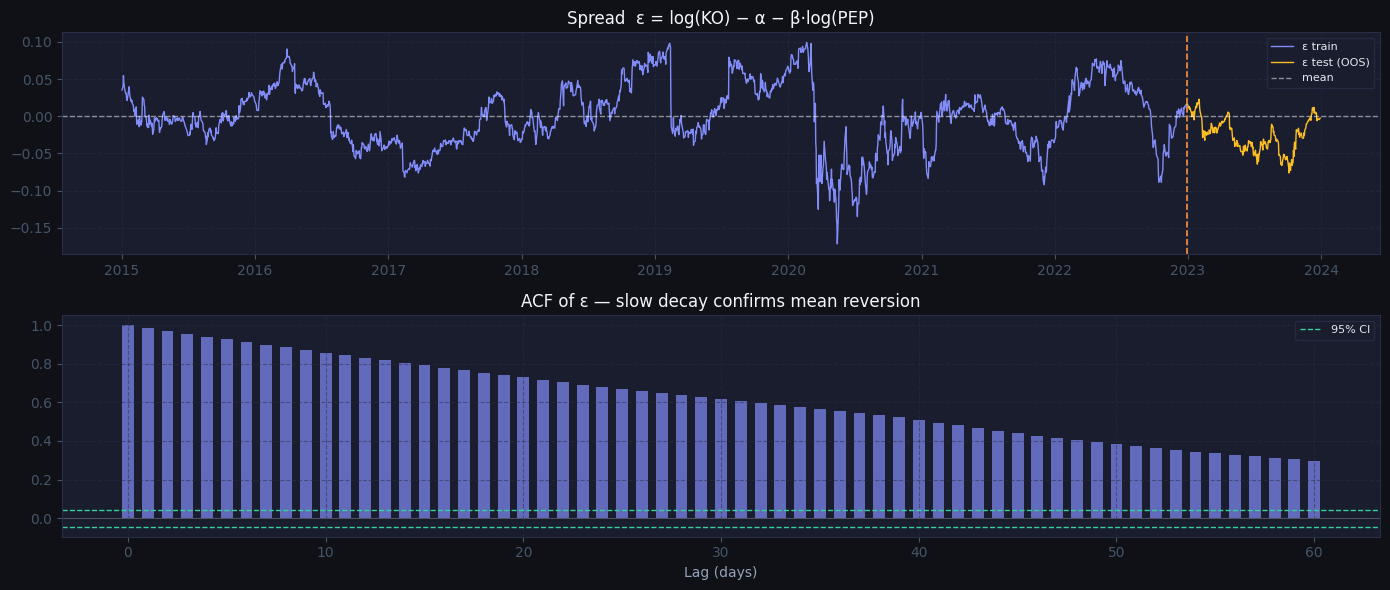

In [6]:
# Spread on FULL sample (using in-sample β)
logA = np.log(prices[TICKER_A])
logB = np.log(prices[TICKER_B])
spread_full = logA - alpha - beta * logB

spread_train = spread_full.iloc[:SPLIT]
spread_test  = spread_full.iloc[SPLIT:]

print("── ADF on the spread ε ──────────────────────────────────────────────")
adf_report(spread_train, 'ε (train)')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# Spread over time
ax = axes[0]
ax.plot(spread_train.index, spread_train, color=PURPLE, lw=1, label='ε train')
ax.plot(spread_test.index,  spread_test,  color=YELLOW, lw=1, label='ε test (OOS)')
ax.axhline(spread_train.mean(), color='white', lw=1, linestyle='--', alpha=0.5, label='mean')
ax.axvline(spread_test.index[0], color=ORANGE, lw=1.2, linestyle='--')
ax.set_title('Spread  ε = log(KO) − α − β·log(PEP)', color='#f1f5f9')
ax.legend(fontsize=8)

# ACF manually
ax2 = axes[1]
s = spread_train - spread_train.mean()
lags = 60
acf_vals = [s.autocorr(lag=l) for l in range(lags+1)]
conf = 1.96 / np.sqrt(len(s))
ax2.bar(range(lags+1), acf_vals, color=PURPLE, alpha=0.7, width=0.6)
ax2.axhline( conf, color=GREEN, lw=1, linestyle='--', label='95% CI')
ax2.axhline(-conf, color=GREEN, lw=1, linestyle='--')
ax2.axhline(0, color='white', lw=0.5, alpha=0.3)
ax2.set_title('ACF of ε — slow decay confirms mean reversion', color='#f1f5f9')
ax2.set_xlabel('Lag (days)'); ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
def fit_ou(spread, dt=1/252):
    """Fit OU parameters via OLS on discrete increments."""
    s  = spread.values
    ds = np.diff(s)
    X  = np.column_stack([np.ones(len(s)-1), s[:-1]])
    coeffs, _, _, _ = np.linalg.lstsq(X, ds, rcond=None)
    a, b = coeffs
    resid      = ds - (a + b * s[:-1])
    sigma_eps  = resid.std(ddof=2)
    theta      = -np.log(1 + b) / dt
    mu_ou      = -a / b
    sigma_ou   = sigma_eps * np.sqrt(2*theta / (1 - np.exp(-2*theta*dt)))
    half_life  = np.log(2) / theta
    sigma_inf  = sigma_ou / np.sqrt(2*theta)
    return dict(theta=theta, mu=mu_ou, sigma=sigma_ou,
                sigma_inf=sigma_inf, half_life=half_life)

ou = fit_ou(spread_train)

print("OU parameters calibrated on TRAIN set")
print(f"  θ (speed)      = {ou['theta']:.4f}")
print(f"  μ_OU (mean)    = {ou['mu']:.6f}")
print(f"  σ              = {ou['sigma']:.6f}")
print(f"  σ∞ (stat std)  = {ou['sigma_inf']:.6f}")
print(f"  Half-life      = {ou['half_life']*252:.1f} trading days  ({ou['half_life']:.3f} yr)")

OU parameters calibrated on TRAIN set
  θ (speed)      = 4.0352
  μ_OU (mean)    = -0.000755
  σ              = 0.124420
  σ∞ (stat std)  = 0.043797
  Half-life      = 43.3 trading days  (0.172 yr)


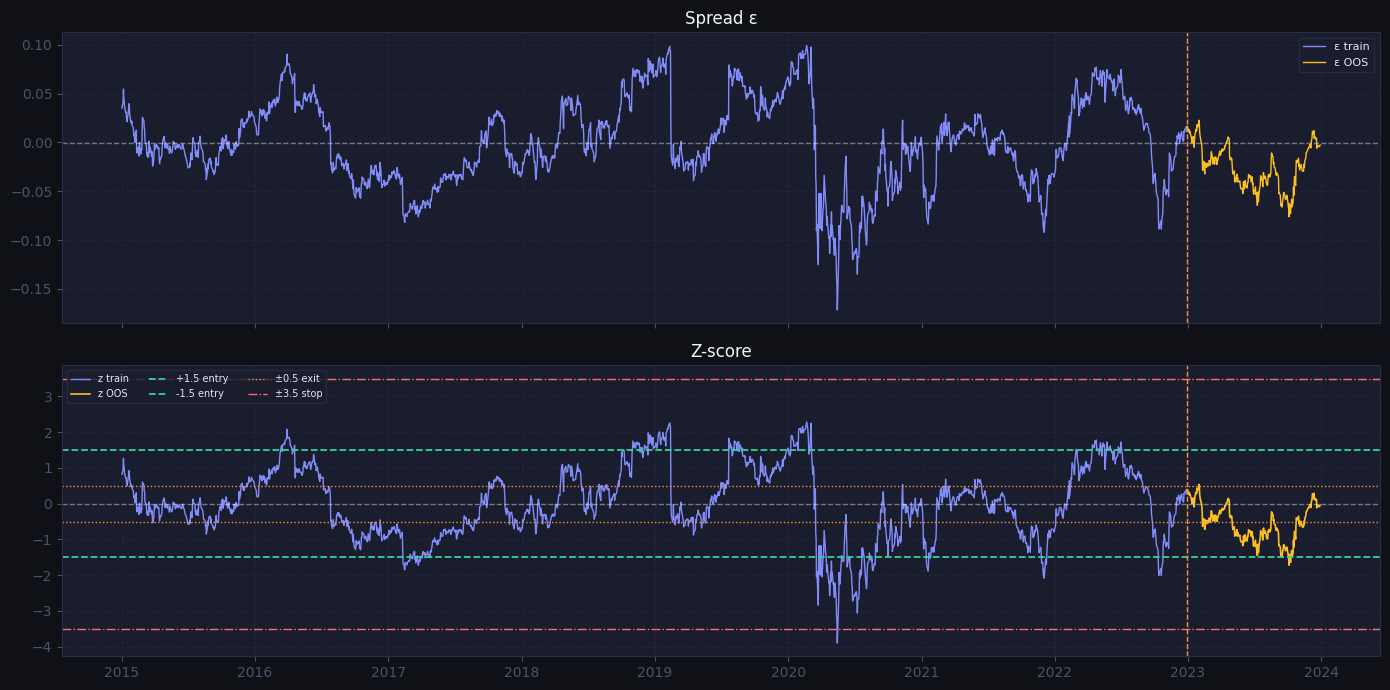

In [ ]:
Z_ENTRY = 1.5
Z_EXIT  = 0.5
Z_STOP  = 3.5

zscore_full = (spread_full - ou['mu']) / ou['sigma_inf']
zscore_train = zscore_full.iloc[:SPLIT]
zscore_test  = zscore_full.iloc[SPLIT:]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# epsilon
ax = axes[0]
ax.plot(spread_train.index, spread_train, color=PURPLE, lw=1, label='ε train')
ax.plot(spread_test.index,  spread_test,  color=YELLOW, lw=1, label='ε OOS')
ax.axhline(ou['mu'], color='white', lw=1, linestyle='--', alpha=0.4)
ax.axvline(spread_test.index[0], color=ORANGE, lw=1, linestyle='--')
ax.set_title('Spread ε', color='#f1f5f9')
ax.legend(fontsize=8)

# z-score
ax2 = axes[1]
ax2.plot(zscore_train.index, zscore_train, color=PURPLE, lw=1, label='z train')
ax2.plot(zscore_test.index,  zscore_test,  color=YELLOW, lw=1.2, label='z OOS')
ax2.axhline(0,        color='white',  lw=1,   linestyle='--', alpha=0.4)
ax2.axhline( Z_ENTRY, color=GREEN,   lw=1.3,  linestyle='--', label=f'+{Z_ENTRY} entry')
ax2.axhline(-Z_ENTRY, color=GREEN,   lw=1.3,  linestyle='--', label=f'-{Z_ENTRY} entry')
ax2.axhline( Z_EXIT,  color=ORANGE,  lw=1,    linestyle=':',  label=f'±{Z_EXIT} exit')
ax2.axhline(-Z_EXIT,  color=ORANGE,  lw=1,    linestyle=':')
ax2.axhline( Z_STOP,  color=RED,     lw=1,    linestyle='-.',  label=f'±{Z_STOP} stop')
ax2.axhline(-Z_STOP,  color=RED,     lw=1,    linestyle='-.')
ax2.axvline(spread_test.index[0], color=ORANGE, lw=1, linestyle='--')
ax2.set_title('Z-score', color='#f1f5f9')
ax2.legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.show()

In [9]:
def backtest(spread, zscore, z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP):
    """
    Simple pairs trading backtest on the spread.
    Position: +1 = long spread, -1 = short spread, 0 = flat
    PnL = position[t] * (spread[t+1] - spread[t])
    """
    n   = len(spread)
    pos = np.zeros(n)
    pnl = np.zeros(n)

    current_pos = 0

    for i in range(1, n):
        z = zscore.iloc[i-1]
        ds = spread.iloc[i] - spread.iloc[i-1]

        # Entry logic (previous day's z-score)
        if current_pos == 0:
            if z < -z_entry:
                current_pos = +1   # long spread
            elif z > +z_entry:
                current_pos = -1   # short spread

        # Exit / stop logic
        elif current_pos == +1:
            if z > -z_exit or z < -z_stop:
                current_pos = 0
        elif current_pos == -1:
            if z < +z_exit or z > +z_stop:
                current_pos = 0

        pos[i] = current_pos
        pnl[i] = current_pos * ds

    results = pd.DataFrame({
        'spread':   spread.values,
        'zscore':   zscore.values,
        'position': pos,
        'pnl':      pnl,
        'cum_pnl':  np.cumsum(pnl)
    }, index=spread.index)

    return results


res_train = backtest(spread_train, zscore_train)
res_test  = backtest(spread_test,  zscore_test)

def perf_stats(res, label):
    daily_pnl = res['pnl']
    n_trades  = (np.diff(res['position'].values) != 0).sum() // 2
    total_pnl = res['cum_pnl'].iloc[-1]
    # Sharpe (annualised, trade days only)
    active = daily_pnl[daily_pnl != 0]
    sharpe = (active.mean() / active.std() * np.sqrt(252)) if len(active) > 1 else 0
    # Max drawdown
    cum = res['cum_pnl']
    dd  = (cum - cum.cummax()).min()
    # Win rate per trade
    wins = (daily_pnl[daily_pnl != 0] > 0).mean()

    print(f"\n── {label} ──────────────────────────────────")
    print(f"  Total PnL    : {total_pnl:+.6f}  (log-spread units)")
    print(f"  Sharpe       : {sharpe:.3f}")
    print(f"  Max drawdown : {dd:.6f}")
    print(f"  N trades     : {n_trades}")
    print(f"  Win rate     : {wins*100:.1f}%")
    return sharpe

perf_stats(res_train, 'TRAIN (in-sample)')
perf_stats(res_test,  'TEST  (out-of-sample)')


── TRAIN (in-sample) ──────────────────────────────────
  Total PnL    : +0.570744  (log-spread units)
  Sharpe       : 1.389
  Max drawdown : -0.138036
  N trades     : 11
  Win rate     : 51.3%

── TEST  (out-of-sample) ──────────────────────────────────
  Total PnL    : +0.050372  (log-spread units)
  Sharpe       : 5.457
  Max drawdown : -0.010101
  N trades     : 1
  Win rate     : 66.7%


np.float64(5.45653069099302)

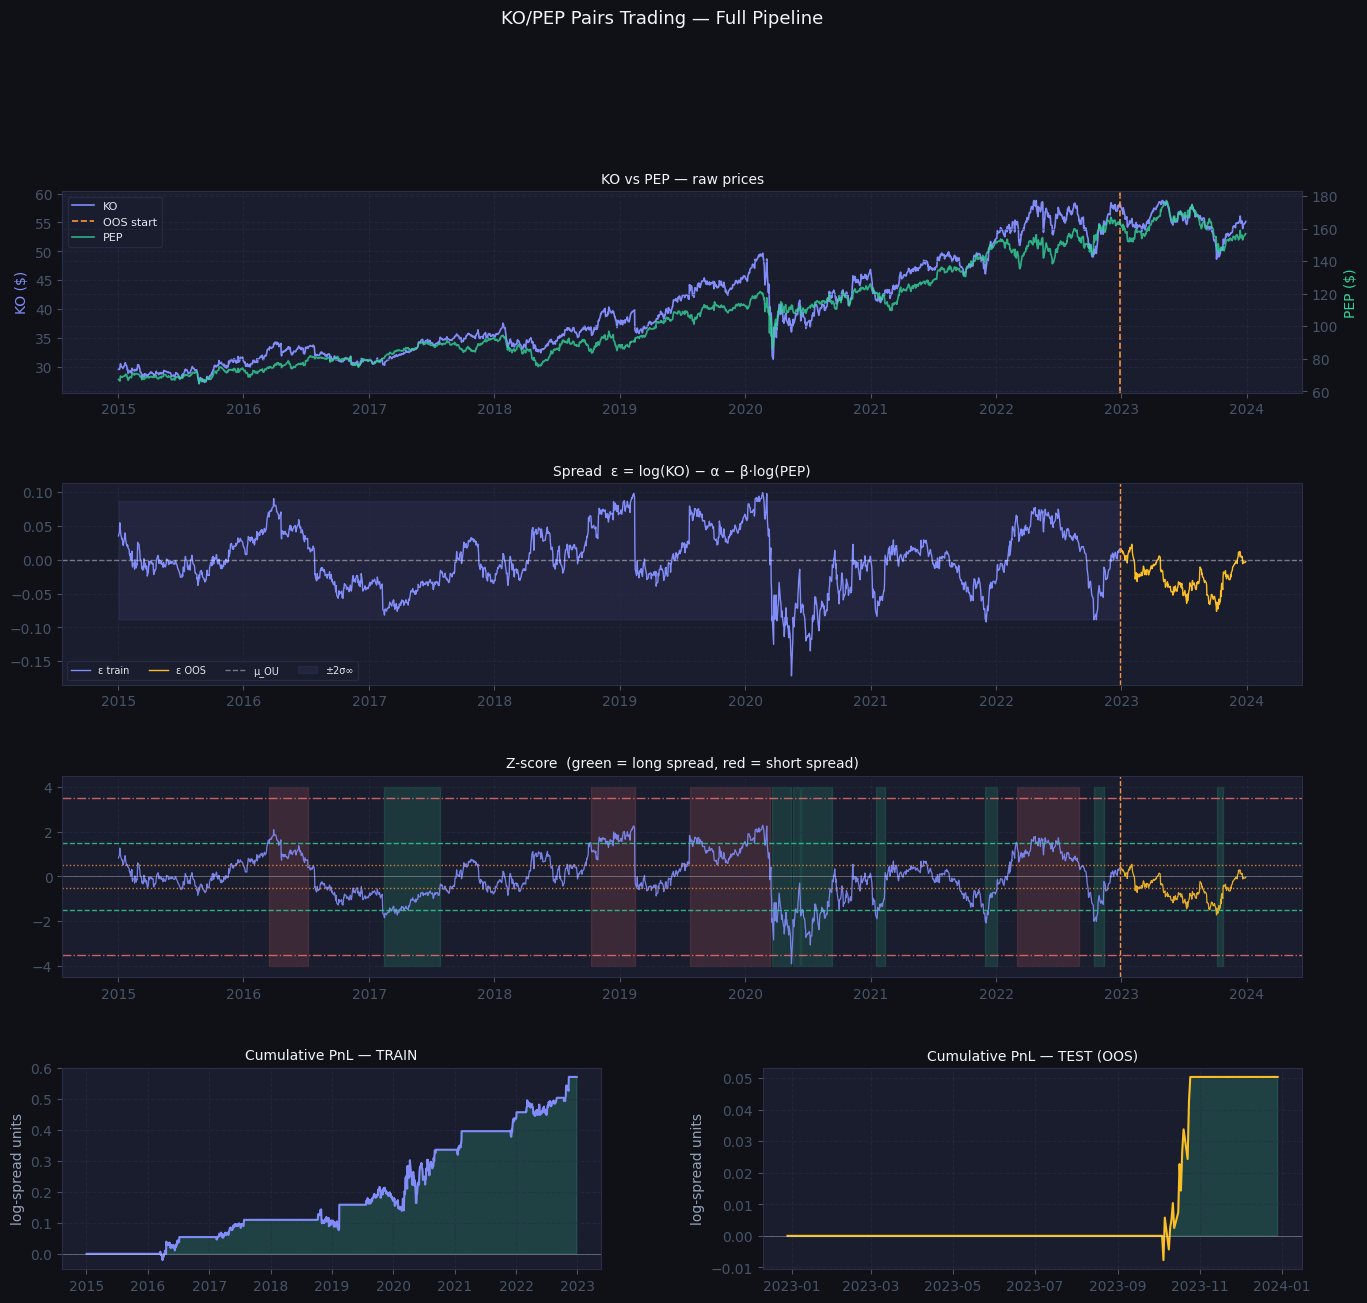

In [ ]:
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

# Prices
ax1 = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()
ax1.plot(prices.index,  prices[TICKER_A], color=PURPLE, lw=1.2, label='KO')
ax1b.plot(prices.index, prices[TICKER_B], color=GREEN,  lw=1.2, label='PEP', alpha=0.8)
ax1.axvline(test.index[0], color=ORANGE, lw=1.2, linestyle='--', label='OOS start')
ax1.set_title('KO vs PEP — raw prices', color='#f1f5f9', fontsize=10)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')
ax1.set_ylabel('KO ($)', color=PURPLE)
ax1b.set_ylabel('PEP ($)', color=GREEN)

# Spread
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(res_train.index, res_train['spread'], color=PURPLE, lw=1, label='ε train')
ax2.plot(res_test.index,  res_test['spread'],  color=YELLOW, lw=1, label='ε OOS')
ax2.axhline(ou['mu'], color='white', lw=1, linestyle='--', alpha=0.4, label='μ_OU')
ax2.fill_between(spread_train.index,
                 ou['mu'] - 2*ou['sigma_inf'],
                 ou['mu'] + 2*ou['sigma_inf'],
                 alpha=0.08, color=PURPLE, label='±2σ∞')
ax2.axvline(test.index[0], color=ORANGE, lw=1, linestyle='--')
ax2.set_title('Spread  ε = log(KO) − α − β·log(PEP)', color='#f1f5f9', fontsize=10)
ax2.legend(fontsize=7, ncol=4)

# Z-score + positions 
ax3 = fig.add_subplot(gs[2, :])
for res, col in [(res_train, PURPLE), (res_test, YELLOW)]:
    ax3.plot(res.index, res['zscore'], color=col, lw=0.9, alpha=0.9)
    long_mask  = res['position'] == +1
    short_mask = res['position'] == -1
    ax3.fill_between(res.index, -4, 4, where=long_mask,  alpha=0.15, color=GREEN)
    ax3.fill_between(res.index, -4, 4, where=short_mask, alpha=0.15, color=RED)

for level, color, ls in [
    ( Z_ENTRY, GREEN,  '--'), (-Z_ENTRY, GREEN,  '--'),
    ( Z_EXIT,  ORANGE, ':'),  (-Z_EXIT,  ORANGE, ':'),
    ( Z_STOP,  RED,    '-.'), (-Z_STOP,  RED,    '-.')
]:
    ax3.axhline(level, color=color, lw=1, linestyle=ls, alpha=0.8)
ax3.axhline(0, color='white', lw=0.7, alpha=0.3)
ax3.axvline(test.index[0], color=ORANGE, lw=1, linestyle='--')
ax3.set_ylim(-4.5, 4.5)
ax3.set_title('Z-score  (green = long spread, red = short spread)', color='#f1f5f9', fontsize=10)

# Cumulative PnL ; train
ax4 = fig.add_subplot(gs[3, 0])
ax4.plot(res_train.index, res_train['cum_pnl'], color=PURPLE, lw=1.5)
ax4.fill_between(res_train.index, 0, res_train['cum_pnl'],
                 where=res_train['cum_pnl'] >= 0, alpha=0.2, color=GREEN)
ax4.fill_between(res_train.index, 0, res_train['cum_pnl'],
                 where=res_train['cum_pnl'] < 0,  alpha=0.2, color=RED)
ax4.axhline(0, color='white', lw=0.7, alpha=0.3)
ax4.set_title('Cumulative PnL — TRAIN', color='#f1f5f9', fontsize=10)
ax4.set_ylabel('log-spread units')

# Cumulative PnL ; test
ax5 = fig.add_subplot(gs[3, 1])
ax5.plot(res_test.index, res_test['cum_pnl'], color=YELLOW, lw=1.5)
ax5.fill_between(res_test.index, 0, res_test['cum_pnl'],
                 where=res_test['cum_pnl'] >= 0, alpha=0.2, color=GREEN)
ax5.fill_between(res_test.index, 0, res_test['cum_pnl'],
                 where=res_test['cum_pnl'] < 0,  alpha=0.2, color=RED)
ax5.axhline(0, color='white', lw=0.7, alpha=0.3)
ax5.set_title('Cumulative PnL — TEST (OOS)', color='#f1f5f9', fontsize=10)
ax5.set_ylabel('log-spread units')

plt.suptitle('KO/PEP Pairs Trading — Full Pipeline', color='#f1f5f9', fontsize=13, y=1.01)
plt.show()

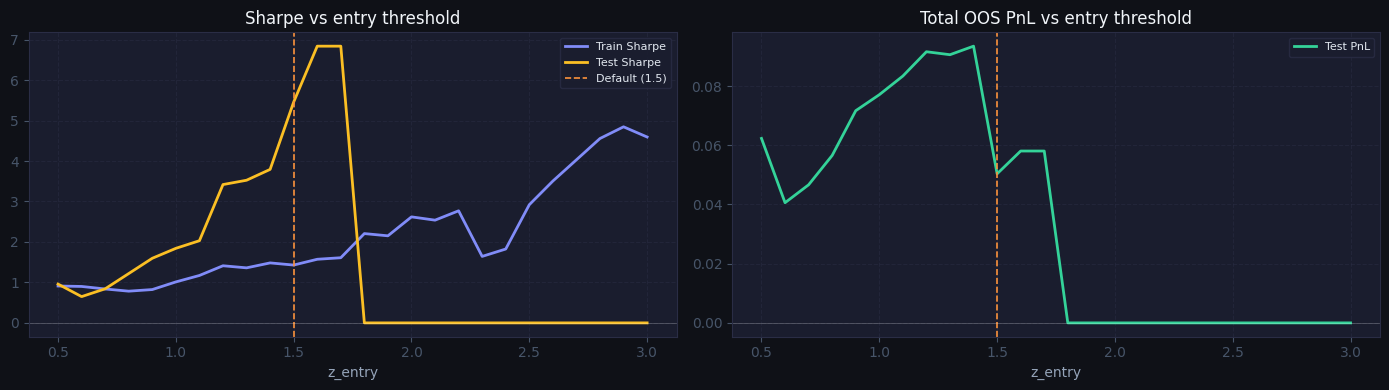

Best OOS Sharpe = 6.838 at z_entry = 1.6


In [11]:
entries   = np.arange(0.5, 3.1, 0.1)
sharpes_train, sharpes_test, pnls_test = [], [], []

for ze in entries:
    r_tr = backtest(spread_train, zscore_train, z_entry=ze, z_exit=ze*0.3, z_stop=ze+2)
    r_te = backtest(spread_test,  zscore_test,  z_entry=ze, z_exit=ze*0.3, z_stop=ze+2)

    def sharpe(r):
        active = r['pnl'][r['pnl'] != 0]
        return (active.mean() / active.std() * np.sqrt(252)) if len(active) > 1 else 0

    sharpes_train.append(sharpe(r_tr))
    sharpes_test.append(sharpe(r_te))
    pnls_test.append(r_te['cum_pnl'].iloc[-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(entries, sharpes_train, color=PURPLE, lw=2, label='Train Sharpe')
axes[0].plot(entries, sharpes_test,  color=YELLOW, lw=2, label='Test Sharpe')
axes[0].axvline(Z_ENTRY, color=ORANGE, lw=1.2, linestyle='--', label=f'Default ({Z_ENTRY})')
axes[0].axhline(0, color='white', lw=0.5, alpha=0.3)
axes[0].set_xlabel('z_entry'); axes[0].set_title('Sharpe vs entry threshold', color='#f1f5f9')
axes[0].legend(fontsize=8)

axes[1].plot(entries, pnls_test, color=GREEN, lw=2, label='Test PnL')
axes[1].axvline(Z_ENTRY, color=ORANGE, lw=1.2, linestyle='--')
axes[1].axhline(0, color='white', lw=0.5, alpha=0.3)
axes[1].set_xlabel('z_entry'); axes[1].set_title('Total OOS PnL vs entry threshold', color='#f1f5f9')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

best_idx = np.argmax(sharpes_test)
print(f"Best OOS Sharpe = {sharpes_test[best_idx]:.3f} at z_entry = {entries[best_idx]:.1f}")